In [1]:
import numpy as np
from scipy import optimize

# 1. Define your well-behaved potential function V(x,y)
# SciPy optimizers require the variables to be passed as a single array/list.
def V(vars):
    x, y = vars
    # Example function: A bowl shape with multiple ripples/minima
    # V(x,y) = x^2 + y^2 - cos(4x) - cos(4y)
    return x**2 + y**2 - np.cos(4*x) - np.cos(4*y)

# ---------------------------------------------------------
# APPROACH A: The Brute Force Grid Search
# ---------------------------------------------------------
print("--- Grid Search ---")
# Define the grid: slice(start, stop, step_size)
grid_ranges = (slice(-3, 3, 0.1), slice(-3, 3, 0.1))

# Run the brute force search. 
# finish=optimize.fmin tells it to "polish" the final answer to exact precision.
grid_result = optimize.brute(V, grid_ranges, full_output=True, finish=optimize.fmin)

print(f"Global Minimum found at: x = {grid_result[0][0]:.5f}, y = {grid_result[0][1]:.5f}")
print(f"Value of V(x,y) there: {grid_result[1]:.5f}\n")

# ---------------------------------------------------------
# THE FASTEST APPROACH: SHGO (Global Optimization)
# ---------------------------------------------------------
print("--- SHGO (Smart Hybrid) ---")
# Define the absolute boundaries of your search area
boundaries = [(-3, 3), (-3, 3)]

# Run the SHGO algorithm
shgo_result = optimize.shgo(V, boundaries)

print(f"Global Minimum found at: x = {shgo_result.x[0]:.5f}, y = {shgo_result.x[1]:.5f}")
print(f"Value of V(x,y) there: {shgo_result.fun:.5f}")

# Bonus: shgo tells you about the other valleys it found!
print("\nOther local minima found by SHGO:")
for i in range(len(shgo_result.funl)):
    print(f"Local Min {i+1}: V = {shgo_result.funl[i]:.5f} at {shgo_result.xl[i]}")

--- Grid Search ---
Global Minimum found at: x = 0.00000, y = 0.00000
Value of V(x,y) there: -2.00000

--- SHGO (Smart Hybrid) ---
Global Minimum found at: x = 0.00000, y = 0.00000
Value of V(x,y) there: -2.00000

Other local minima found by SHGO:
Local Min 1: V = -2.00000 at [0. 0.]


In [3]:
import numpy as np
from scipy import optimize
import time  # Import the timing library

# Define your potential function V(x,y)
def V(vars):
    x, y = vars
    # A standard smooth function with multiple ripples/minima
    return x**4 + y**4 - 10*y**3

# Define boundaries for the search
boundaries = [(-100, 100), (-100, 100)]
grid_ranges = (slice(-100, 100, 0.1), slice(-100, 100, 0.1))

# ---------------------------------------------------------
# TIMING APPROACH A: Brute Force Grid Search
# ---------------------------------------------------------
print("Running Grid Search...")
start_time = time.perf_counter()  # Start the clock

grid_result = optimize.brute(V, grid_ranges, full_output=True, finish=optimize.fmin)

end_time = time.perf_counter()  # Stop the clock
grid_duration = end_time - start_time  # Calculate elapsed time

print(f"Grid Search Found: V = {grid_result[1]:.5f} at x={grid_result[0][0]:.3f}, y={grid_result[0][1]:.3f}")
print(f"Execution Time: {grid_duration:.6f} seconds\n")

# ---------------------------------------------------------
# TIMING THE HYBRID APPROACH: SHGO
# ---------------------------------------------------------
print("Running SHGO Global Optimization...")
start_time = time.perf_counter()  # Start the clock

shgo_result = optimize.shgo(V, boundaries,n=1000)

end_time = time.perf_counter()  # Stop the clock
shgo_duration = end_time - start_time  # Calculate elapsed time

print(f"SHGO Found: V = {shgo_result.fun:.5f} at x={shgo_result.x[0]:.3f}, y={shgo_result.x[1]:.3f}")
print(f"Execution Time: {shgo_duration:.6f} seconds\n")

# ---------------------------------------------------------
# FINAL COMPARISON
# ---------------------------------------------------------
print("--- Performance Verdict ---")
speedup = grid_duration / shgo_duration
print(f"SHGO is {speedup:.1f}x faster than Grid Search on this test.")

Running Grid Search...
Grid Search Found: V = -1054.68750 at x=0.000, y=7.500
Execution Time: 7.072660 seconds

Running SHGO Global Optimization...
SHGO Found: V = -1054.68750 at x=-0.018, y=7.500
Execution Time: 0.048174 seconds

--- Performance Verdict ---
SHGO is 146.8x faster than Grid Search on this test.


In [71]:
from xSM_Model import xSM
import numpy as np
from scipy.optimize import shgo
import time

def physical_to_lagrangian(m1, m2, theta, v, u, lHS, lS):
    """
    Convert physical parameters to xSM Lagrangian parameters.

    Inputs
    ------
    m1, m2  : scalar mass eigenvalues (GeV), m1 < m2 convention
    theta   : mixing angle (rad)
    v, u    : Higgs and singlet vevs (GeV)
    lHS     : quartic portal lambda_HS
    lS      : singlet quartic lambda_S

    Outputs
    -------
    dict with keys: lH, muHS, mu3, muH2, muS2
    (lHS and lS are inputs, returned unchanged for completeness)
    """
    ct = np.cos(theta)
    st = np.sin(theta)
    
    Mhh = m1**2 * ct**2 + m2**2 * st**2
    Mss = m1**2 * st**2 + m2**2 * ct**2
    Mhs = (m1**2 - m2**2) * ct * st
    
    lH   = Mhh / (2.0 * v**2)

    muHS = Mhs / v  -  lHS * u

    # Relations don't hold if u=0
    if abs(u) > 1e-6:
        mu3 = (2.0*lS*u**2  -  Mss  -  muHS*v**2/(2.0*u)) / u
    else:
        mu3 = 0.0   

    # Mass parameters from tadpole conditions
    muH2 = lH*v**2  +  0.5*lHS*u**2  +  muHS*u
    if abs(u) > 1e-6:
        muS2 = 0.5*lHS*v**2  +  muHS*v**2/(2.0*u)  +  lS*u**2  -  mu3*u
    else:
        muS2 = 0.0

    return dict(lH=lH, lHS=lHS, muHS=muHS, lS=lS, mu3=mu3, muH2=muH2, muS2=muS2)

# Define the parameters
v0 = 246.22
u0 = 500.0
params = physical_to_lagrangian(
    m1    = 125.20,   # GeV  
    m2    = 60.0,    # GeV 
    theta = 0.01,      # rad  
    v     = v0,   # GeV
    u     = u0,     # GeV 
    lHS   = 0.05,     #     
    lS    = 0.05,      #     
)

model = xSM(**{k: params[k] for k in ['lH','lHS','muHS','lS','mu3']},
            v=v0, u=u0)
v = model.v_os
u = model.u_os

# Start the timer before the optimization runs
start_time = time.perf_counter()

# Run SHGO global optimization
res = shgo(
    lambda x: model.Vtot(np.array([[x[0], x[1]]]), 0.0).item(),
    bounds=[(0, 350), (-200, 1000)],
    n=200 # Optional: Adjust sampling density if the space is too large
)

# End the timer immediately after it finishes
end_time = time.perf_counter()
execution_time = end_time - start_time

# Extract the optimized coordinates
v_num, u_num = res.x

print(f"Global Minimum found at: v = {v:.3f}, u = {u:.3f}")
print(f"Global Minimum found at: v = {v_num:.3f}, u = {u_num:.3f}")
print(f"SHGO optimization finished in {execution_time:.6f} seconds.")
if not np.isclose(v_num, v, atol=0.5) or not np.isclose(u_num, u, atol=0.5):
    print("Potential is Metastable")
else:
    print("Saul Good Man")

Global Minimum found at: v = 246.220, u = 500.000
Global Minimum found at: v = 150.791, u = 28.313
SHGO optimization finished in 0.124231 seconds.
Potential is Metastable


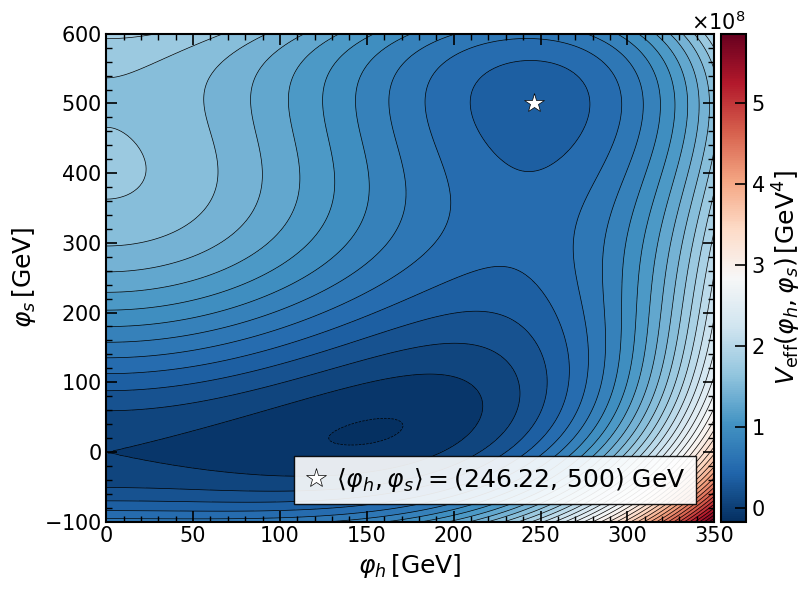

In [81]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import ScalarFormatter

# Grid in (h, s)
h_vals = np.linspace(0, 350, 200)
s_vals = np.linspace(-100, 600, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.Vtot(X_grid, 0.0).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 100))
V_shifted = V_plot - model.Vtot(np.array([[0.0, 0.0]]), 0.0)

norm = Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())  # Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())  TwoSlopeNorm(vcenter=0, vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=50, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=50, colors='k', linewidths=0.5, alpha=1)
ax.plot(v, u, 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$\langle\varphi_h, \varphi_s\rangle = ({v:.2f},\,{u:.0f})$ GeV')

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_\mathrm{eff}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0.9, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.savefig(r"Stability_CheckV1.pdf", format="pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

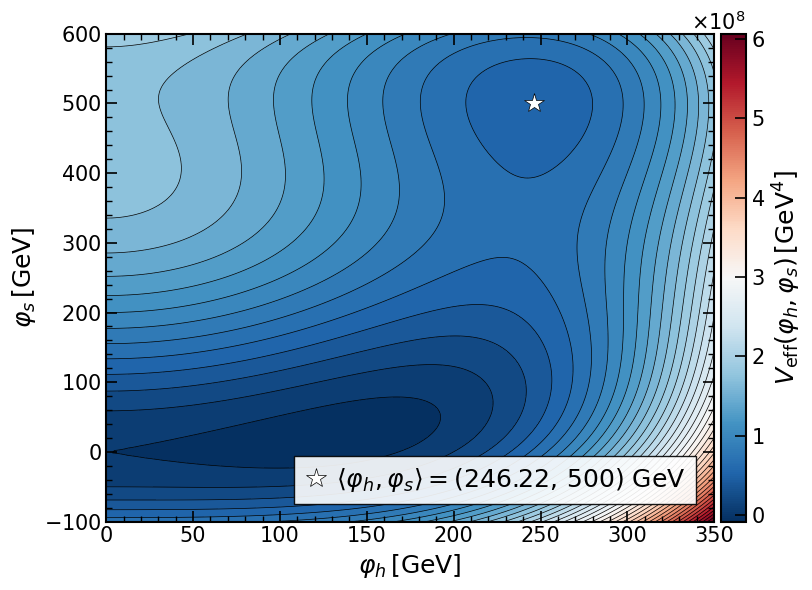

In [83]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import ScalarFormatter

# Grid in (h, s)
h_vals = np.linspace(0, 350, 200)
s_vals = np.linspace(-100, 600, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.V0(X_grid).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 100))
V_shifted = V_plot - model.V0(np.array([[0.0, 0.0]]))

norm = Normalize(vmin=V_shifted.min(), vmax=V_shifted.max()) #TwoSlopeNorm(vcenter=0, vmin=V_shifted.min(), vmax=V_shifted.max()) 
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=50, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=50, colors='k', linewidths=0.5, alpha=1)
ax.plot(v, u, 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$\langle\varphi_h, \varphi_s\rangle = ({v:.2f},\,{u:.0f})$ GeV')

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_\mathrm{eff}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0.9, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.savefig(r"Stability_CheckV0.pdf", format="pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

In [49]:
print(params)

{'lH': 0.1292702392878693, 'lHS': 0.05, 'muHS': -24.50961599328108, 'lS': 0.05, 'mu3': 45.769341129599034, 'muH2': 1832.1082714842578, 'muS2': -10354.941383349444}
